<a href="https://colab.research.google.com/github/DemaAlRoud/MLDiabetesPrediction/blob/main/MLDiabetesPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from keras.models import Sequential
from keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay, roc_curve
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

In [ ]:
#loading dataset
data = pd.read_csv("diabetes_prediction_dataset.csv")

data = pd.get_dummies(data, columns=['gender', 'smoking_history'], drop_first=True)

X = data.drop("diabetes", axis=1)
y = data["diabetes"]

#scaling data
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptro

MLP Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18292
           1       0.97      0.68      0.80      1708

    accuracy                           0.97     20000
   macro avg       0.97      0.84      0.89     20000
weighted avg       0.97      0.97      0.97     20000

Confusion Matrix: [[18258    34]
 [  541  1167]]
AUC Score: 0.9772632108788424


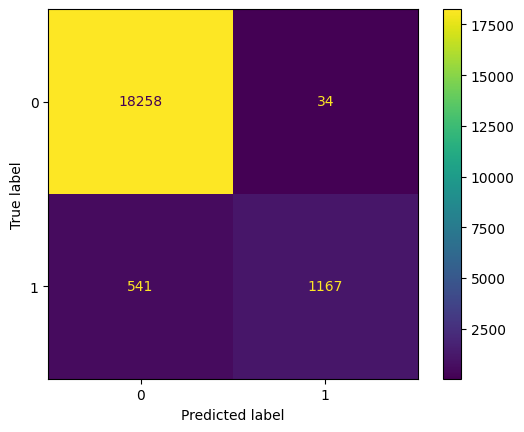

Text(0.5, 1.0, 'MLP ROC Curve')

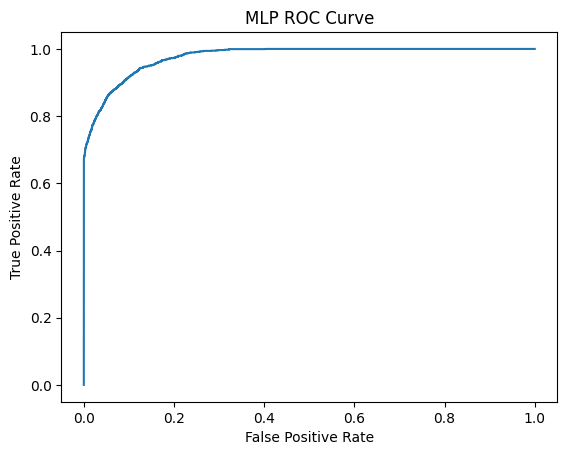

In [ ]:
#MLP model implementation
mlpModel = MLPClassifier(max_iter=200, random_state=42)

#hyperparameters tuning
param_grid = {
    'hidden_layer_sizes': [(32,), (32, 32), (64, 64)],
    'activation': ['relu', 'tanh'],
    'batch_size': [32, 64],
    'learning_rate_init': [0.001, 0.01]
}

gridMLP = GridSearchCV(estimator=mlpModel, param_grid=param_grid,
                    cv=3, scoring='accuracy', verbose=1)

#MLP model training
gridMLPTrain = gridMLP.fit(X_train, y_train)

#MLP model performance evaluation
bestMLP = gridMLPTrain.best_estimator_
mlp_preds = bestMLP.predict(X_test)
mlp_probs = bestMLP.predict_proba(X_test)[:, 1]

print("MLP Classification Report:")
print(classification_report(y_test, mlp_preds))
mlp_cm = confusion_matrix(y_test, mlp_preds)
print("Confusion Matrix:",mlp_cm)
print("AUC Score:", roc_auc_score(y_test, mlp_probs))

#ModelPerformanceVisualization
ConfusionMatrixDisplay(mlp_cm).plot()
plt.show()

fpr, tpr, _ = roc_curve(y_test, mlp_probs)
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("MLP ROC Curve")

SVM Classification Report
              precision    recall  f1-score   support

           0       0.99      0.89      0.94     18292
           1       0.43      0.89      0.58      1708

    accuracy                           0.89     20000
   macro avg       0.71      0.89      0.76     20000
weighted avg       0.94      0.89      0.91     20000

Confusion Matrix:   [[16280  2012]
 [  183  1525]]
AUC Score: 0.9616678417664829


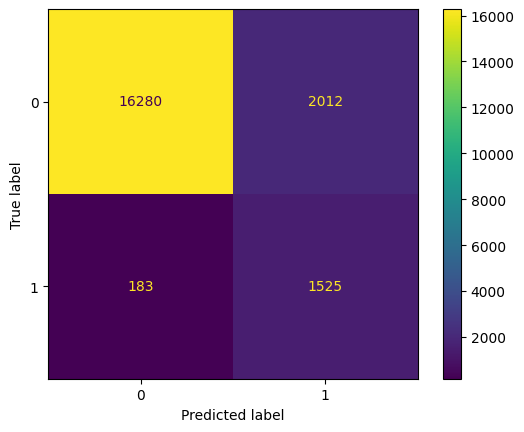

Text(0.5, 1.0, 'SVM ROC Curve')

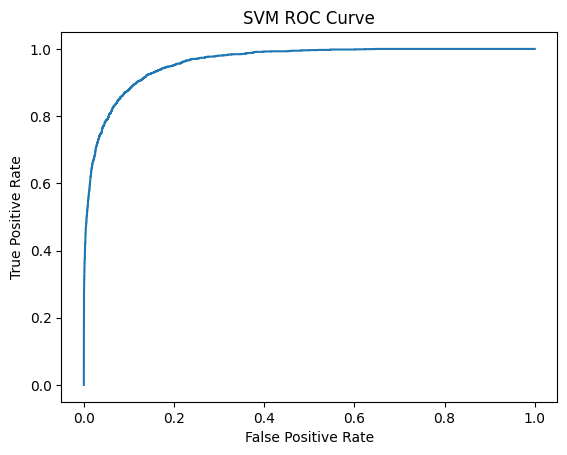

In [ ]:
#SVM model implementation
svmModel = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42)
#tuuning hyperparameters
svmParam_grid = {
    'C': [1],
    'gamma': ['scale'],
    'kernel': ['rbf']
}

gridSvm = GridSearchCV(svmModel, svmParam_grid, cv=5, scoring='roc_auc')

#SVM model training
gridSvm.fit(X_train, y_train)

#SVM model performance evaluation
svm_preds = gridSvm.predict(X_test)
svm_probs = gridSvm.predict_proba(X_test)[:, 1]

print("SVM Classification Report")
print( classification_report(y_test, svm_preds))
svm_cm = confusion_matrix(y_test, svm_preds)
print("Confusion Matrix:  ", svm_cm)
print("AUC Score:", roc_auc_score(y_test, svm_probs))

#ModelPerformanceVisualization
ConfusionMatrixDisplay(svm_cm).plot()
plt.show()

fpr, tpr, _ = roc_curve(y_test, svm_probs)
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM ROC Curve")

Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.99      0.92      0.95     18292
           1       0.50      0.90      0.64      1708

    accuracy                           0.91     20000
   macro avg       0.74      0.91      0.80     20000
weighted avg       0.95      0.91      0.92     20000

Confusion Matrix:  [[16745  1547]
 [  175  1533]]
AUC Score: 0.9765188778601208


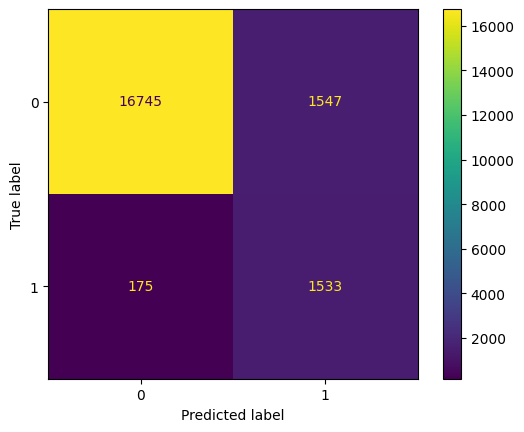

Text(0.5, 1.0, 'RF ROC Curve')

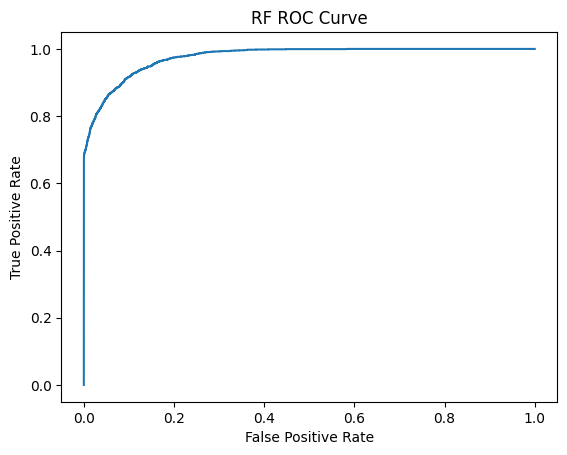

In [ ]:
from sklearn.ensemble import RandomForestClassifier

#Random Forest model implementation
randomForestModel = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

#tuuning hyperparameters
rfParam_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'class_weight': ['balanced']
}

gridRF = GridSearchCV(randomForestModel, rfParam_grid, cv=5, scoring='roc_auc')

#Random Forest model training
gridRF.fit(X_train, y_train)

#Random Forest model performance evaluation
rf_preds = gridRF.predict(X_test)
rf_probs = gridRF.predict_proba(X_test)[:, 1]

print("Random Forest Classification Report")
print( classification_report(y_test, rf_preds))
rf_cm = confusion_matrix(y_test, rf_preds)
print("Confusion Matrix: ", rf_cm)
print("AUC Score:", roc_auc_score(y_test, rf_probs))

#ModelPerformanceVisualization
ConfusionMatrixDisplay(rf_cm).plot()
plt.show()

fpr, tpr, _ = roc_curve(y_test, rf_probs)
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("RF ROC Curve")